<a href="https://colab.research.google.com/github/ehsankarami1358/LOKA_HYDRO/blob/main/LOKA_U4_TRANS_ANALYSE_R2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# ============================================================
# ADVANCED TRANSFORMER UNIT-4 HEALTH ANALYSIS
# Electrical + Temperature + Fan Group 1/2 + ML + Aging + Anomaly
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except:
    XGB_AVAILABLE = False


In [29]:

# ============================================================
# 1) FILE PATHS - UNIT 4
# ============================================================

elec_path = Path(r"/content/u4_electrical_20_5_2026_R1_2.csv")
temp_path = Path(r"/content/u4_trans_temp_20_5_2026_R1_2.csv")

fan1_path = Path(r"/content/fan_group1_u4_R1.xls")
fan2_path = Path(r"/content/fan_group2_u4_R1.xls")

output_excel = "Transformer_U4_Advanced_Status_Report.xlsx"

# Approximation because real ambient temperature is not available
AMBIENT_TEMP_C = 25

# Adjust if Unit 4 transformer rating is different
TRANSFORMER_RATED_MVA = 190


In [30]:
# ============================================================
# 2) HELPER FUNCTIONS
# ============================================================

def read_xls_safely(path):
    try:
        return pd.read_excel(path)
    except Exception:
        outdir = path.parent
        subprocess.run([
            "libreoffice", "--headless", "--convert-to", "xlsx",
            "--outdir", str(outdir), str(path)
        ], check=True)
        return pd.read_excel(path.with_suffix(".xlsx"))


def process_fan_file(path, group_name):
    fan = read_xls_safely(path)

    time_col = None
    for col in fan.columns:
        if "time" in col.lower() or "date" in col.lower():
            time_col = col
            break

    if time_col is None:
        time_col = fan.columns[0]

    desc_col = fan.columns[-1]

    fan["Timestamp"] = pd.to_datetime(
        fan[time_col],
        errors="coerce",
        dayfirst=True
    )

    fan = fan.dropna(subset=["Timestamp"]).sort_values("Timestamp")

    text = fan[desc_col].astype(str)

    fan[group_name] = np.where(
        text.str.contains("N-ACTIVE -> ACTIVE", case=False, na=False) |
        text.str.contains("OFF -> ON", case=False, na=False) |
        text.str.contains("0 -> 1", case=False, na=False),
        1,
        np.where(
            text.str.contains("ACTIVE -> N-ACTIVE", case=False, na=False) |
            text.str.contains("ON -> OFF", case=False, na=False) |
            text.str.contains("1 -> 0", case=False, na=False),
            0,
            np.nan
        )
    )

    fan = fan.dropna(subset=[group_name])

    return fan[["Timestamp", group_name]]


def normalize_bad(value, good, bad):
    score = 100 - ((value - good) / (bad - good) * 100)
    return np.clip(score, 0, 100)


In [33]:

# ============================================================
# 3) READ DATA
# ============================================================

elec = pd.read_csv(elec_path)
temp = pd.read_csv(temp_path, encoding='utf-16', sep='\t')

elec["Timestamp"] = pd.to_datetime(elec["Timestamp"], errors="coerce", dayfirst=True)
temp["Timestamp"] = pd.to_datetime(temp["Timestamp"], errors="coerce", dayfirst=True)

elec = elec.dropna(subset=["Timestamp"]).sort_values("Timestamp")
temp = temp.dropna(subset=["Timestamp"]).sort_values("Timestamp")

In [39]:
# ============================================================
# 4) RENAME UNIT 4 COLUMNS
# ============================================================

elec = elec.rename(columns={
    "ACTIVE POWER MEAS VALUE": "MW",
    "REACTIVE POWER MEAS VALUE": "MVAr",

    "VOLTAGE PHASE AB": "HV_AB_kV",
    "VOLTAGE PHASE BC": "HV_BC_kV",
    "VOLTAGE PHASE CA": "HV_CA_kV",

    "UNIT VOLTAGE PHASE AB": "LV_AB_kV",
    "UNIT VOLTAGE PHASE BC": "LV_BC_kV",
    "UNIT VOLTAGE PHASE CA": "LV_CA_kV",

    "ADM BUSBAR VOLTAGE PHASE TO PHASE": "ADM_Busbar_kV",
    "UNIT FREQUENCY": "Frequency_Hz",
    "ADM TOTAL ACTIVE POWER": "ADM_Total_MW",
})

# Dynamic renaming for 'temp' to handle potential variations in original column names
rename_map_temp = {}
winding_temp_cols_found = []

# Identify winding temp columns that already follow the 'Winding_Temp_X_C' pattern
for col in temp.columns:
    if col.startswith("Winding_Temp_") and col.endswith("_C"):
        winding_temp_cols_found.append(col)

# Sort them to ensure consistent naming (e.g., .1, .2 suffix order if they had them)
winding_temp_cols_found.sort()

# Map winding temperatures to their own names (effectively no change if they are already named correctly)
# Only proceed if we found exactly 3 winding temp columns as expected
if len(winding_temp_cols_found) == 3:
    for i, original_name in enumerate(winding_temp_cols_found):
        rename_map_temp[original_name] = f"Winding_Temp_{i+1}_C"

# Now, find the oil temperature column by excluding Timestamp and identified winding temps.
# Based on the kernel state showing 5 columns for 'temp' and 3 winding temps found,
# plus 'Timestamp', the 5th column is most likely the oil temperature.
non_standard_cols = [
    col for col in temp.columns
    if col != "Timestamp" and col not in winding_temp_cols_found
]

oil_temp_col_found = None
if len(non_standard_cols) == 1:
    # If only one non-standard column left, assume it's the oil temperature
    oil_temp_col_found = non_standard_cols[0]
elif len(non_standard_cols) > 1:
    # If more than one, try a more lenient search for 'OIL' or 'TEMP'
    for col in non_standard_cols:
        col_upper = col.upper()
        if "OIL" in col_upper or "TEMP" in col_upper:
            oil_temp_col_found = col
            break

if oil_temp_col_found:
    rename_map_temp[oil_temp_col_found] = "Oil_Temp_C"
else:
    raise KeyError(
        "Could not uniquely identify the oil temperature column in temp DataFrame. "
        "Please inspect 'temp.columns' for its actual name and manually add it to the rename map if needed."
    )

temp = temp.rename(columns=rename_map_temp)

In [40]:
# ============================================================
# 5) MERGE ELECTRICAL + TEMPERATURE
# ============================================================

df = pd.merge_asof(
    elec.sort_values("Timestamp"),
    temp.sort_values("Timestamp"),
    on="Timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("10min")
)

# Ensure 'Oil_Temp_C' column exists before dropping NaNs
if "Oil_Temp_C" not in df.columns:
    found_oil_col = None
    for col in df.columns:
        if "OIL" in col.upper() and "TEMP" in col.upper():
            found_oil_col = col
            break
    if found_oil_col:
        df = df.rename(columns={found_oil_col: "Oil_Temp_C"})
    else:
        raise KeyError("Failed to identify and rename the oil temperature column to 'Oil_Temp_C'.")

df = df.dropna(subset=["MW", "Oil_Temp_C"]).sort_values("Timestamp")
df = df[df["MW"] >= 0]

In [41]:
# ============================================================
# 6) FAN GROUP 1 + FAN GROUP 2
# ============================================================

fan1 = process_fan_file(fan1_path, "Fan_Group_1_Status")
fan2 = process_fan_file(fan2_path, "Fan_Group_2_Status")

df = pd.merge_asof(
    df.sort_values("Timestamp"),
    fan1.sort_values("Timestamp"),
    on="Timestamp",
    direction="backward"
)

df = pd.merge_asof(
    df.sort_values("Timestamp"),
    fan2.sort_values("Timestamp"),
    on="Timestamp",
    direction="backward"
)

df["Fan_Group_1_Status"] = df["Fan_Group_1_Status"].fillna(0)
df["Fan_Group_2_Status"] = df["Fan_Group_2_Status"].fillna(0)

df["Total_Fan_Groups_ON"] = (
    df["Fan_Group_1_Status"] +
    df["Fan_Group_2_Status"]
)


In [42]:
# ============================================================
# 7) BASIC ELECTRICAL KPIs
# ============================================================

df["ApparentPower_MVA"] = np.sqrt(df["MW"]**2 + df["MVAr"]**2)
df["Load_Percent"] = df["ApparentPower_MVA"] / TRANSFORMER_RATED_MVA * 100
df["PowerFactor"] = df["MW"] / df["ApparentPower_MVA"].replace(0, np.nan)

df["HV_avg_kV"] = df[["HV_AB_kV", "HV_BC_kV", "HV_CA_kV"]].mean(axis=1)

df["HV_imbalance_percent"] = (
    df[["HV_AB_kV", "HV_BC_kV", "HV_CA_kV"]]
    .sub(df["HV_avg_kV"], axis=0)
    .abs()
    .max(axis=1)
    / df["HV_avg_kV"] * 100
)

df["LV_avg_kV"] = df[["LV_AB_kV", "LV_BC_kV", "LV_CA_kV"]].mean(axis=1)

df["LV_imbalance_percent"] = (
    df[["LV_AB_kV", "LV_BC_kV", "LV_CA_kV"]]
    .sub(df["LV_avg_kV"], axis=0)
    .abs()
    .max(axis=1)
    / df["LV_avg_kV"] * 100
)


In [43]:
# ============================================================
# 8) THERMAL KPIs
# ============================================================

df["Winding_Avg_C"] = df[
    ["Winding_Temp_1_C", "Winding_Temp_2_C", "Winding_Temp_3_C"]
].mean(axis=1)

df["Winding_Max_C"] = df[
    ["Winding_Temp_1_C", "Winding_Temp_2_C", "Winding_Temp_3_C"]
].max(axis=1)

df["Winding_Spread_C"] = (
    df[["Winding_Temp_1_C", "Winding_Temp_2_C", "Winding_Temp_3_C"]].max(axis=1)
    -
    df[["Winding_Temp_1_C", "Winding_Temp_2_C", "Winding_Temp_3_C"]].min(axis=1)
)

df["Ambient_Temp_C"] = AMBIENT_TEMP_C

df["Oil_Rise_Over_Ambient_C"] = df["Oil_Temp_C"] - df["Ambient_Temp_C"]
df["Winding_Rise_Over_Ambient_C"] = df["Winding_Avg_C"] - df["Ambient_Temp_C"]

df["Winding_Oil_Gradient_C"] = df["Winding_Avg_C"] - df["Oil_Temp_C"]
df["MaxWinding_Oil_Gradient_C"] = df["Winding_Max_C"] - df["Oil_Temp_C"]

df["Cooling_Efficiency_KPI"] = (
    df["Oil_Rise_Over_Ambient_C"] /
    df["ApparentPower_MVA"].replace(0, np.nan)
)

df["Thermal_Load_Index"] = (
    df["Oil_Temp_C"] /
    df["ApparentPower_MVA"].replace(0, np.nan)
)



In [44]:
# ============================================================
# 9) DYNAMIC THERMAL FEATURES
# ============================================================

df = df.sort_values("Timestamp")

for lag in [1, 2, 3, 6, 12]:
    df[f"MW_lag_{lag}"] = df["MW"].shift(lag)
    df[f"MVA_lag_{lag}"] = df["ApparentPower_MVA"].shift(lag)
    df[f"OilTemp_lag_{lag}"] = df["Oil_Temp_C"].shift(lag)
    df[f"WindingTemp_lag_{lag}"] = df["Winding_Avg_C"].shift(lag)

df["MW_rolling_6_mean"] = df["MW"].rolling(6).mean()
df["MVA_rolling_6_mean"] = df["ApparentPower_MVA"].rolling(6).mean()
df["OilTemp_rolling_6_mean"] = df["Oil_Temp_C"].rolling(6).mean()
df["WindingTemp_rolling_6_mean"] = df["Winding_Avg_C"].rolling(6).mean()

df["OilTemp_Rate_C_per_sample"] = df["Oil_Temp_C"].diff()
df["WindingTemp_Rate_C_per_sample"] = df["Winding_Avg_C"].diff()

In [45]:

# ============================================================
# 10) AGING / REMAINING LIFE ESTIMATION
# ============================================================

df["Estimated_Hotspot_C"] = df["Winding_Max_C"] + 10

df["Aging_Acceleration_Factor"] = np.exp(
    (15000 / 383) - (15000 / (df["Estimated_Hotspot_C"] + 273))
)

df["Equivalent_Aging_Hours"] = df["Aging_Acceleration_Factor"]
df["Cumulative_Aging_Hours"] = df["Equivalent_Aging_Hours"].cumsum()

df["Life_Consumption_Percent"] = (
    df["Cumulative_Aging_Hours"] / 180000 * 100
)



In [46]:
# ============================================================
# 11) FAST ML PREDICTION MODEL
# Predict winding average temperature
# ============================================================

feature_cols = [
    "MW", "MVAr", "ApparentPower_MVA", "Load_Percent", "PowerFactor",
    "HV_imbalance_percent", "LV_imbalance_percent",
    "Oil_Temp_C", "Ambient_Temp_C",
    "Fan_Group_1_Status", "Fan_Group_2_Status", "Total_Fan_Groups_ON",

    "MW_lag_1", "MW_lag_2", "MW_lag_3", "MW_lag_6",
    "MVA_lag_1", "MVA_lag_2", "MVA_lag_3", "MVA_lag_6",
    "OilTemp_lag_1", "OilTemp_lag_2", "OilTemp_lag_3", "OilTemp_lag_6",

    "MW_rolling_6_mean",
    "MVA_rolling_6_mean",
    "OilTemp_rolling_6_mean"
]

model_df = df.dropna(subset=feature_cols + ["Winding_Avg_C"]).copy()

# Optional: reduce very large dataset size for speed
MAX_ROWS_FOR_ML = 30000

if len(model_df) > MAX_ROWS_FOR_ML:
    model_df = model_df.iloc[::max(1, len(model_df)//MAX_ROWS_FOR_ML)].copy()

X = model_df[feature_cols]
y = model_df["Winding_Avg_C"]

split_index = int(len(model_df) * 0.75)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=80,       # reduced from 300
        max_depth=8,           # reduced from 12
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
}

# Use XGBoost only if dataset is not too large
if XGB_AVAILABLE and len(model_df) < 20000:
    models["XGBoost"] = XGBRegressor(
        n_estimators=120,      # reduced from 400
        max_depth=3,           # reduced from 5
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=2
    )

metrics_rows = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    metrics_rows.append({
        "Model": name,
        "Train_R2": r2_score(y_train, train_pred),
        "Test_R2": r2_score(y_test, test_pred),
        "Train_MAE_C": mean_absolute_error(y_train, train_pred),
        "Test_MAE_C": mean_absolute_error(y_test, test_pred),
        "Train_RMSE_C": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test_RMSE_C": np.sqrt(mean_squared_error(y_test, test_pred)),
    })

    model_df[f"{name}_Predicted_Winding_C"] = model.predict(X)
    model_df[f"{name}_Residual_C"] = (
        model_df["Winding_Avg_C"] -
        model_df[f"{name}_Predicted_Winding_C"]
    )

ml_metrics = pd.DataFrame(metrics_rows)

best_model_name = ml_metrics.sort_values("Test_MAE_C").iloc[0]["Model"]
best_pred_col = f"{best_model_name}_Predicted_Winding_C"
best_residual_col = f"{best_model_name}_Residual_C"

df = df.merge(
    model_df[["Timestamp", best_pred_col, best_residual_col]],
    on="Timestamp",
    how="left"
)

print("\nML model completed successfully")
print(ml_metrics)

Training RandomForest...
Training XGBoost...

ML model completed successfully
          Model  Train_R2   Test_R2  Train_MAE_C  Test_MAE_C  Train_RMSE_C  \
0  RandomForest  0.965921  0.762401     0.390212    0.777611      0.532764   
1       XGBoost  0.978454  0.788255     0.319096    0.719001      0.423617   

   Test_RMSE_C  
0     1.047790  
1     0.989141  


In [47]:

# ============================================================
# 12) ANOMALY DETECTION
# ============================================================

anomaly_features = [
    "MW", "MVAr", "ApparentPower_MVA",
    "Oil_Temp_C", "Winding_Avg_C", "Winding_Max_C",
    "Winding_Spread_C", "Winding_Oil_Gradient_C",
    "HV_imbalance_percent", "LV_imbalance_percent",
    "Cooling_Efficiency_KPI",
    "Total_Fan_Groups_ON"
]

anom_df = df.dropna(subset=anomaly_features).copy()

scaler = StandardScaler()
X_anom = scaler.fit_transform(anom_df[anomaly_features])

iso = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42
)

anom_df["Anomaly_Label"] = iso.fit_predict(X_anom)
anom_df["Anomaly_Score"] = iso.decision_function(X_anom)
anom_df["Is_Anomaly"] = np.where(anom_df["Anomaly_Label"] == -1, 1, 0)

df = df.merge(
    anom_df[["Timestamp", "Anomaly_Score", "Is_Anomaly"]],
    on="Timestamp",
    how="left"
)

df["Is_Anomaly"] = df["Is_Anomaly"].fillna(0)



In [48]:

# ============================================================
# 13) ADVANCED HEALTH SCORE
# ============================================================

df["Oil_Temp_Score"] = normalize_bad(df["Oil_Temp_C"], 60, 90)
df["Winding_Temp_Score"] = normalize_bad(df["Winding_Max_C"], 70, 110)
df["HV_Imbalance_Score"] = normalize_bad(df["HV_imbalance_percent"], 0.5, 2.0)
df["LV_Imbalance_Score"] = normalize_bad(df["LV_imbalance_percent"], 0.3, 1.5)
df["Cooling_Score"] = normalize_bad(df["Cooling_Efficiency_KPI"], 0.15, 0.40)
df["Aging_Score"] = normalize_bad(df["Aging_Acceleration_Factor"], 1.0, 5.0)
df["Winding_Spread_Score"] = normalize_bad(df["Winding_Spread_C"], 3, 10)

df["Anomaly_Score_Component"] = np.where(df["Is_Anomaly"] == 1, 60, 100)

df["Advanced_Transformer_Health_Score"] = (
    0.18 * df["Oil_Temp_Score"] +
    0.20 * df["Winding_Temp_Score"] +
    0.10 * df["HV_Imbalance_Score"] +
    0.05 * df["LV_Imbalance_Score"] +
    0.12 * df["Cooling_Score"] +
    0.15 * df["Aging_Score"] +
    0.10 * df["Winding_Spread_Score"] +
    0.10 * df["Anomaly_Score_Component"]
)



In [49]:

# ============================================================
# 14) SUMMARY
# ============================================================

summary = pd.DataFrame({
    "Parameter": [
        "Average MW",
        "Maximum MW",
        "Average MVA",
        "Maximum MVA",
        "Average Load %",
        "Maximum Load %",
        "Average Oil Temp",
        "Maximum Oil Temp",
        "Average Winding Temp",
        "Maximum Winding Temp",
        "Average Winding Spread",
        "Maximum Winding Spread",
        "Average Cooling Efficiency KPI",
        "Maximum Cooling Efficiency KPI",
        "Average Aging Acceleration Factor",
        "Maximum Aging Acceleration Factor",
        "Estimated Life Consumption %",
        "Average HV Imbalance %",
        "Maximum HV Imbalance %",
        "Average LV Imbalance %",
        "Maximum LV Imbalance %",
        "Detected Anomaly Count",
        "Anomaly Percent",
        "Average Advanced Health Score",
        "Minimum Advanced Health Score"
    ],
    "Value": [
        df["MW"].mean(),
        df["MW"].max(),
        df["ApparentPower_MVA"].mean(),
        df["ApparentPower_MVA"].max(),
        df["Load_Percent"].mean(),
        df["Load_Percent"].max(),
        df["Oil_Temp_C"].mean(),
        df["Oil_Temp_C"].max(),
        df["Winding_Avg_C"].mean(),
        df["Winding_Max_C"].max(),
        df["Winding_Spread_C"].mean(),
        df["Winding_Spread_C"].max(),
        df["Cooling_Efficiency_KPI"].mean(),
        df["Cooling_Efficiency_KPI"].max(),
        df["Aging_Acceleration_Factor"].mean(),
        df["Aging_Acceleration_Factor"].max(),
        df["Life_Consumption_Percent"].max(),
        df["HV_imbalance_percent"].mean(),
        df["HV_imbalance_percent"].max(),
        df["LV_imbalance_percent"].mean(),
        df["LV_imbalance_percent"].max(),
        df["Is_Anomaly"].sum(),
        df["Is_Anomaly"].mean() * 100,
        df["Advanced_Transformer_Health_Score"].mean(),
        df["Advanced_Transformer_Health_Score"].min()
    ]
})

print("\n========== ML MODEL METRICS ==========")
print(ml_metrics)

print("\n========== UNIT 4 TRANSFORMER SUMMARY ==========")
print(summary)

avg_health = df["Advanced_Transformer_Health_Score"].mean()

if avg_health >= 85:
    status = "GOOD"
elif avg_health >= 70:
    status = "NORMAL / WATCH"
else:
    status = "ATTENTION REQUIRED"

print("\n========== FINAL UNIT 4 TRANSFORMER STATUS ==========")
print("Status:", status)
print(f"Average Advanced Health Score: {avg_health:.2f}")




========== ML MODEL METRICS ==========
          Model  Train_R2   Test_R2  Train_MAE_C  Test_MAE_C  Train_RMSE_C  \
0  RandomForest  0.965921  0.762401     0.390212    0.777611      0.532764   
1       XGBoost  0.978454  0.788255     0.319096    0.719001      0.423617   

   Test_RMSE_C  
0     1.047790  
1     0.989141  

========== UNIT 4 TRANSFORMER SUMMARY ==========
                            Parameter      Value
0                          Average MW  25.284393
1                          Maximum MW  31.844030
2                         Average MVA  25.827928
3                         Maximum MVA  32.219906
4                      Average Load %  13.593646
5                      Maximum Load %  16.957845
6                    Average Oil Temp  40.691919
7                    Maximum Oil Temp  54.807210
8                Average Winding Temp  30.737865
9                Maximum Winding Temp  54.845830
10             Average Winding Spread  33.264477
11             Maximum Winding Sprea

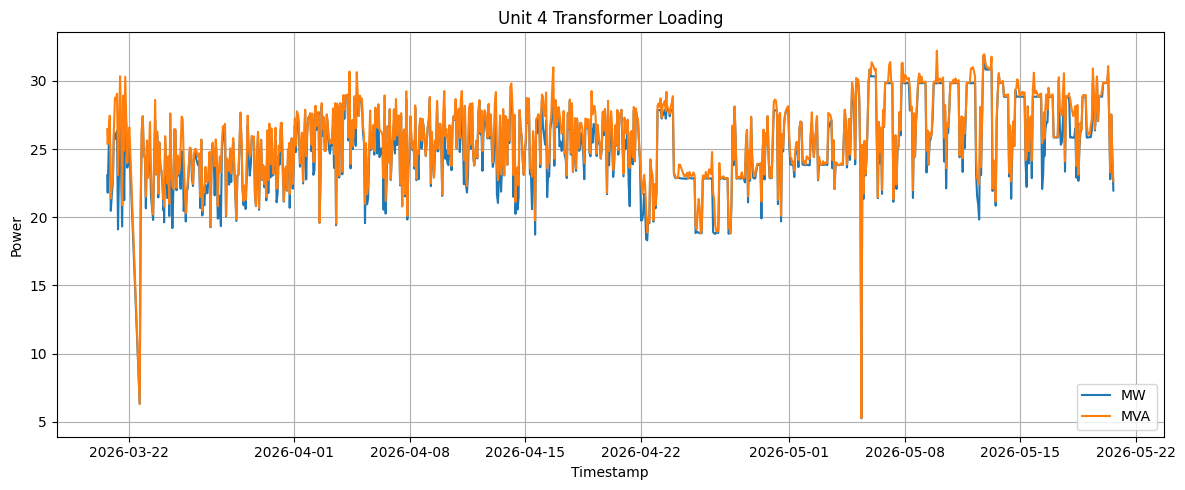

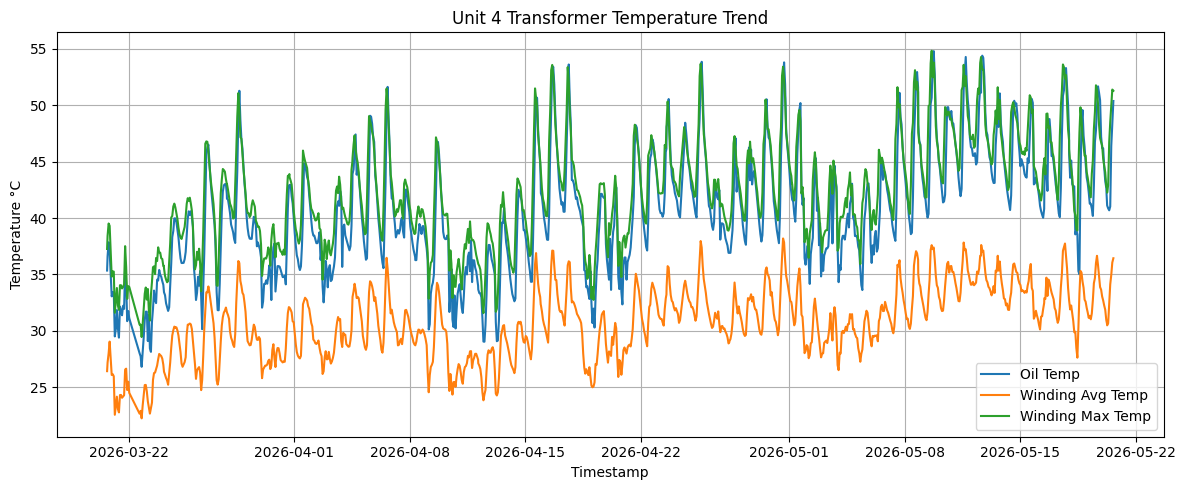

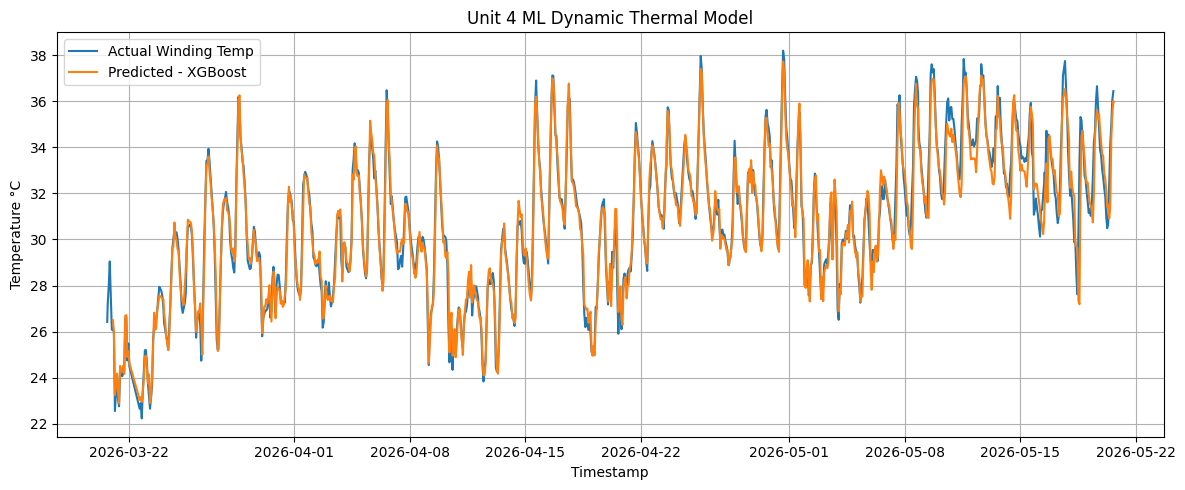

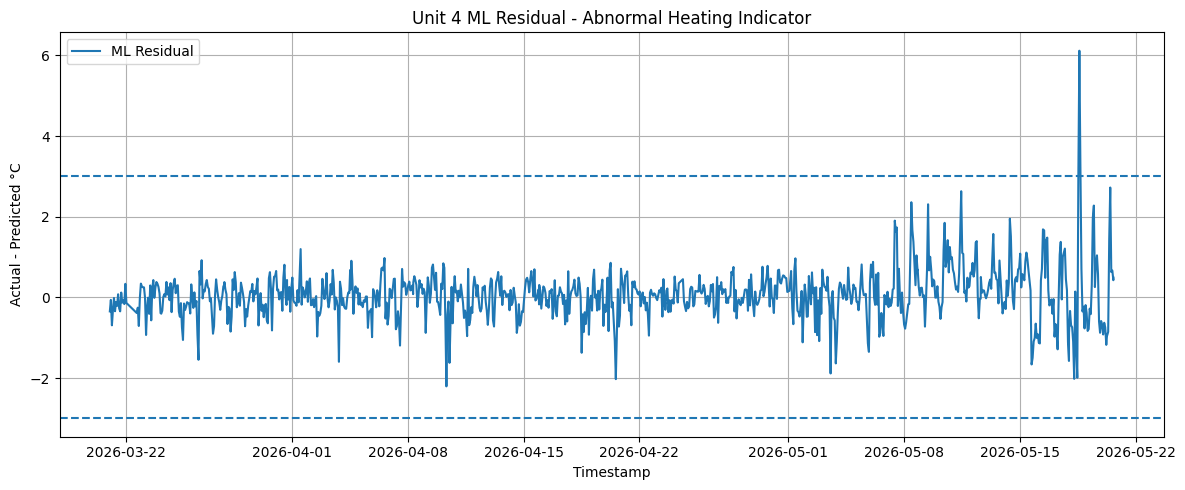

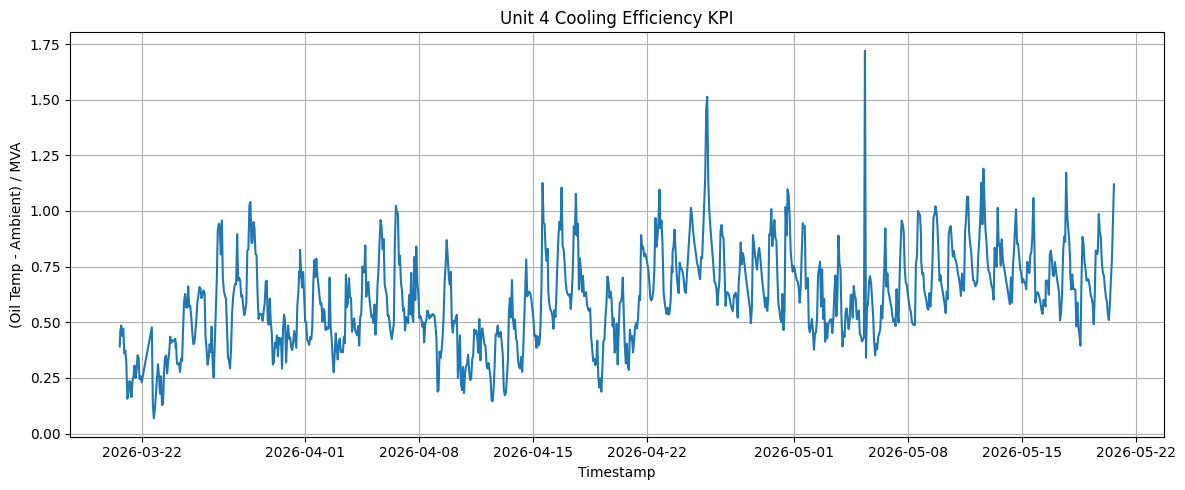

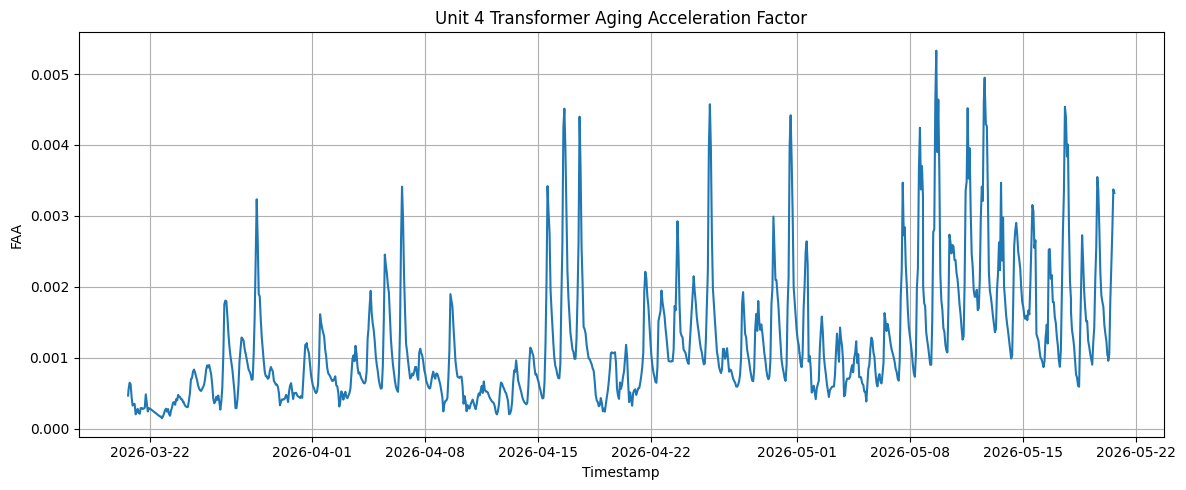

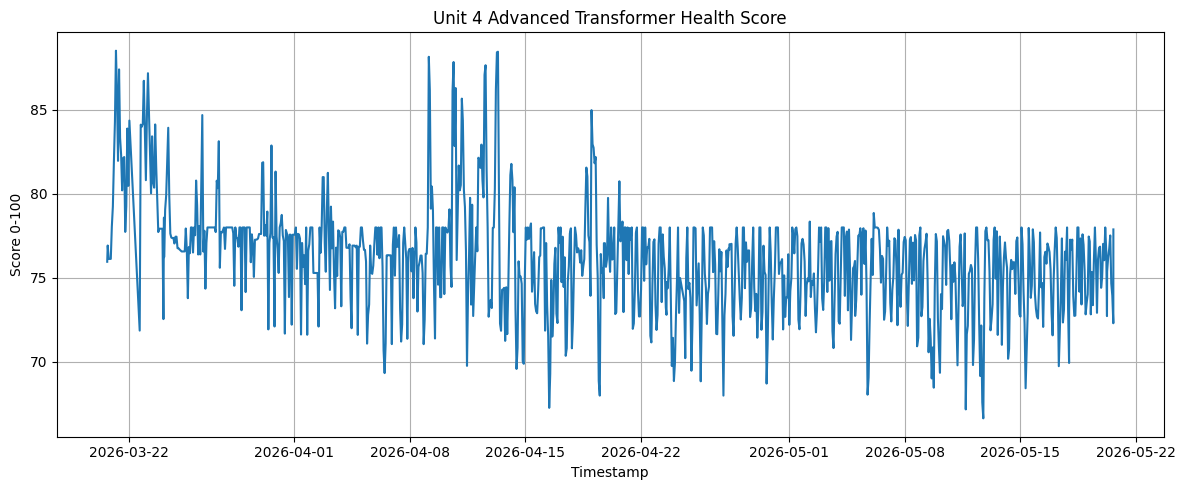

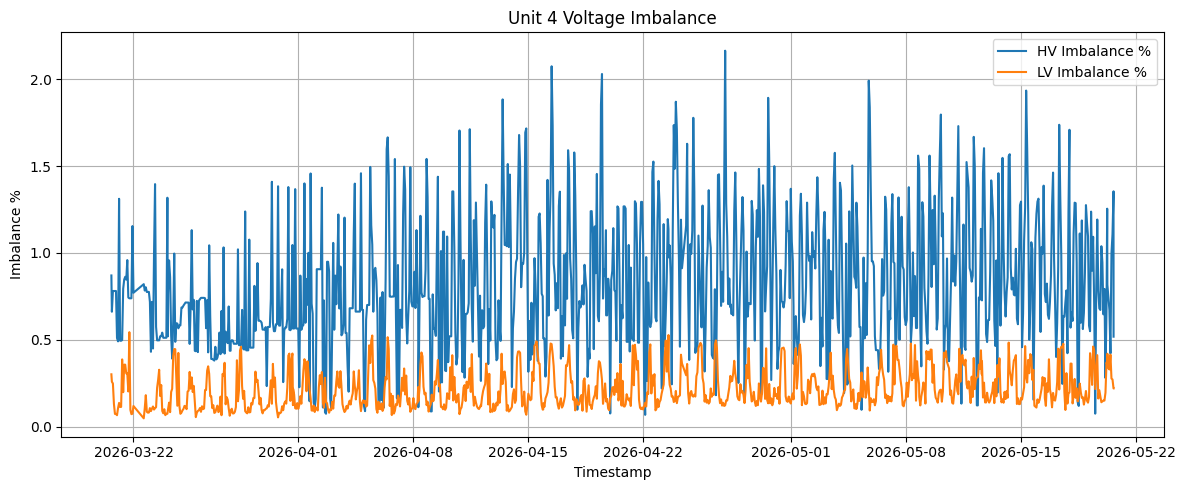

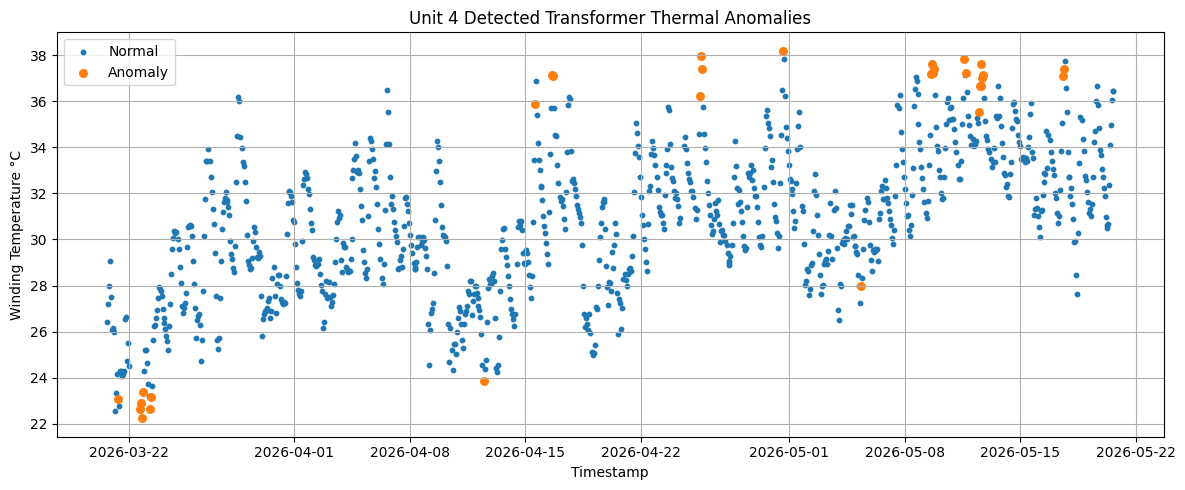

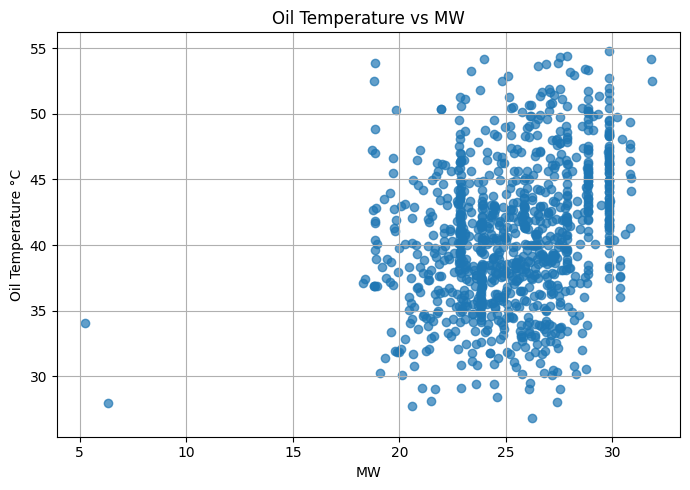

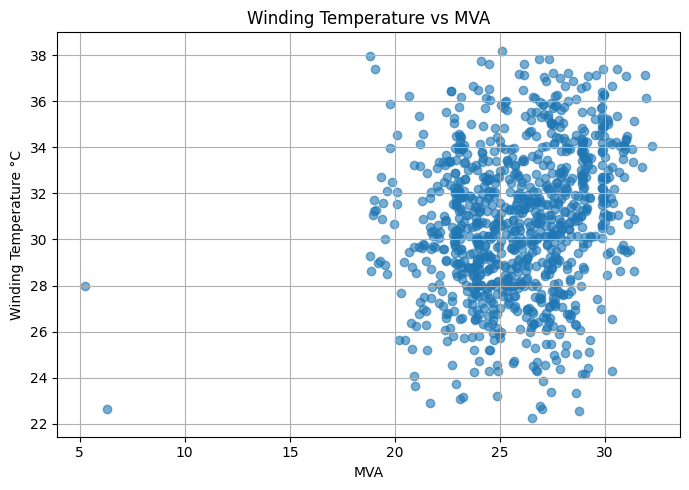

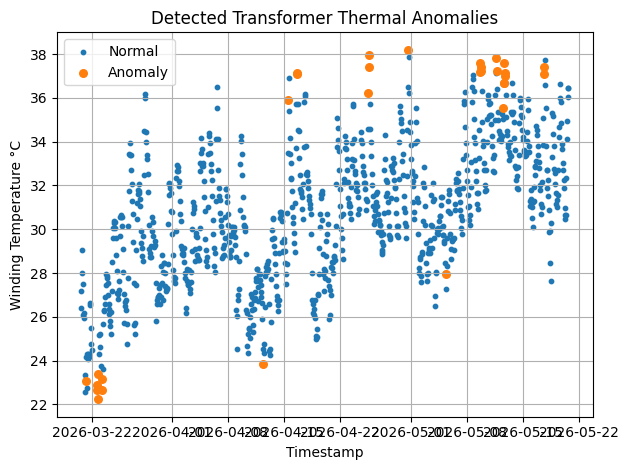

In [52]:

# ============================================================
# 15) PLOTS
# ============================================================

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["MW"], label="MW")
plt.plot(df["Timestamp"], df["ApparentPower_MVA"], label="MVA")
plt.title("Unit 4 Transformer Loading")
plt.xlabel("Timestamp")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["Oil_Temp_C"], label="Oil Temp")
plt.plot(df["Timestamp"], df["Winding_Avg_C"], label="Winding Avg Temp")
plt.plot(df["Timestamp"], df["Winding_Max_C"], label="Winding Max Temp")
plt.title("Unit 4 Transformer Temperature Trend")
plt.xlabel("Timestamp")
plt.ylabel("Temperature °C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["Winding_Avg_C"], label="Actual Winding Temp")
plt.plot(df["Timestamp"], df[best_pred_col], label=f"Predicted - {best_model_name}")
plt.title("Unit 4 ML Dynamic Thermal Model")
plt.xlabel("Timestamp")
plt.ylabel("Temperature °C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df[best_residual_col], label="ML Residual")
plt.axhline(3, linestyle="--")
plt.axhline(-3, linestyle="--")
plt.title("Unit 4 ML Residual - Abnormal Heating Indicator")
plt.xlabel("Timestamp")
plt.ylabel("Actual - Predicted °C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["Cooling_Efficiency_KPI"])
plt.title("Unit 4 Cooling Efficiency KPI")
plt.xlabel("Timestamp")
plt.ylabel("(Oil Temp - Ambient) / MVA")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["Aging_Acceleration_Factor"])
plt.title("Unit 4 Transformer Aging Acceleration Factor")
plt.xlabel("Timestamp")
plt.ylabel("FAA")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["Advanced_Transformer_Health_Score"])
plt.title("Unit 4 Advanced Transformer Health Score")
plt.xlabel("Timestamp")
plt.ylabel("Score 0-100")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"], df["HV_imbalance_percent"], label="HV Imbalance %")
plt.plot(df["Timestamp"], df["LV_imbalance_percent"], label="LV Imbalance %")
plt.title("Unit 4 Voltage Imbalance")
plt.xlabel("Timestamp")
plt.ylabel("Imbalance %")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
normal = df[df["Is_Anomaly"] == 0]
anom = df[df["Is_Anomaly"] == 1]

plt.scatter(normal["Timestamp"], normal["Winding_Avg_C"], s=10, label="Normal")
plt.scatter(anom["Timestamp"], anom["Winding_Avg_C"], s=30, label="Anomaly")
plt.title("Unit 4 Detected Transformer Thermal Anomalies")
plt.xlabel("Timestamp")
plt.ylabel("Winding Temperature °C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df["MW"], df["Oil_Temp_C"], alpha=0.7)
plt.title("Oil Temperature vs MW")
plt.xlabel("MW")
plt.ylabel("Oil Temperature °C")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df["ApparentPower_MVA"], df["Winding_Avg_C"], alpha=0.6)
plt.title("Winding Temperature vs MVA")
plt.xlabel("MVA")
plt.ylabel("Winding Temperature °C")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.scatter(normal["Timestamp"], normal["Winding_Avg_C"], s=10, label="Normal")
plt.scatter(anom["Timestamp"], anom["Winding_Avg_C"], s=30, label="Anomaly")
plt.title("Detected Transformer Thermal Anomalies")
plt.xlabel("Timestamp")
plt.ylabel("Winding Temperature °C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [51]:
# ============================================================
# 16) EXPORT EXCEL
# ============================================================

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Advanced_Merged_Data", index=False)
    summary.to_excel(writer, sheet_name="Summary", index=False)
    ml_metrics.to_excel(writer, sheet_name="ML_Model_Metrics", index=False)
    fan1.to_excel(writer, sheet_name="Fan_Group_1_Events", index=False)
    fan2.to_excel(writer, sheet_name="Fan_Group_2_Events", index=False)

print(f"\nAdvanced Unit 4 Excel report saved: {output_excel}")


Advanced Unit 4 Excel report saved: Transformer_U4_Advanced_Status_Report.xlsx
